In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, TimeDistributed, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Install datasets library
!pip install -q datasets
from datasets import load_dataset

In [27]:
# 1. Load BC5CDR dataset using the specified repository
from datasets import load_dataset

try:
    # Using the user-suggested repository
    dataset = load_dataset("disi-unibo-nlp/bc5cdr")
except Exception as e:
    print(f"Primary load failed: {e}. Trying alternative...")
    dataset = load_dataset("Babelscape/bc5cdr")

print("Dataset Structure:\n", dataset)

# Identify the label field
train_features = dataset['train'].features
tag_field = 'ner_tags' if 'ner_tags' in train_features else 'tags'

# Extract labels and label count
label_list = train_features[tag_field].feature.names
num_labels = len(label_list)

print(f"\nLabels identified: {label_list}")
print(f"Number of labels: {num_labels}")
print("Sample record:", dataset['train'][0])

README.md:   0%|          | 0.00/535 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/378k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/375k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/394k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4560 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4581 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4797 [00:00<?, ? examples/s]

Dataset Structure:
 DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 4560
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 4581
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 4797
    })
})


AttributeError: 'Value' object has no attribute 'names'

In [43]:
# 2. Preprocessing - Offset labels to reserve 0 for padding
MAX_LEN = 128
VOCAB_SIZE = 10000
EMBEDDING_DIM = 100

train_features = dataset['train'].features
tag_field = 'ner_tags' if 'ner_tags' in train_features else 'tags'

try:
    label_list = train_features[tag_field].feature.names
except AttributeError:
    label_list = ['O', 'B-Chemical', 'I-Chemical', 'B-Disease', 'I-Disease']

num_labels = len(label_list) + 1  # Add 1 to account for padding (index 0)
label_to_id = {name: i + 1 for i, name in enumerate(label_list)} # Labels start at 1

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts([' '.join(x['tokens']) for x in dataset['train']])

def prepare_data(ds_split):
    sentences = [' '.join(x['tokens']) for x in ds_split]
    sequences = tokenizer.texts_to_sequences(sentences)
    X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

    processed_labels = []
    for tags in ds_split[tag_field]:
        if len(tags) > 0 and isinstance(tags[0], str):
            processed_labels.append([label_to_id.get(t, 1) for t in tags])
        else:
            # If tags are already IDs, shift them by 1
            processed_labels.append([t + 1 for t in tags])

    y = pad_sequences(processed_labels, maxlen=MAX_LEN, padding='post', truncating='post', value=0)
    y = tf.keras.utils.to_categorical(y, num_classes=num_labels)
    return X, y

X_train, y_train = prepare_data(dataset['train'])
X_val, y_val = prepare_data(dataset['validation'])
X_test, y_test = prepare_data(dataset['test'])

print(f"Label Mapping (Padding is 0): {label_to_id}")
print(f"X_train shape: {X_train.shape}")

Label Mapping (Padding is 0): {'O': 1, 'B-Chemical': 2, 'I-Chemical': 3, 'B-Disease': 4, 'I-Disease': 5}
X_train shape: (4560, 128)


In [44]:
def build_model(optimizer_name='adam', learning_rate=0.001):
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
        Dropout(0.3),
        Bidirectional(LSTM(units=64, return_sequences=True, kernel_regularizer=l2(0.01))),
        TimeDistributed(Dense(num_labels, activation='softmax'))
    ])

    if optimizer_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Show summary with the updated num_labels
build_model().summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 128, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 128, 128)       │        84,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 128, 6)         │           774 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085,254 (4.14 MB)

 Trainable params: 1,085,254 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
results = {}
optimizers = ['sgd', 'adam', 'rmsprop']

for opt_name in optimizers:
    print(f"\n--- Training with {opt_name.upper()} ---")
    model = build_model(optimizer_name=opt_name)
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )
    results[opt_name] = history.history
    if opt_name == 'adam':
        model.save("BC5CDR_ner_model.h5")


--- Training with SGD ---
Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7937 - loss: 4.4583 - val_accuracy: 0.8001 - val_loss: 4.2798
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7977 - loss: 4.1210 - val_accuracy: 0.8001 - val_loss: 3.9623
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7977 - loss: 3.8306 - val_accuracy: 0.8001 - val_loss: 3.7024
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7977 - loss: 3.6111 - val_accuracy: 0.8001 - val_loss: 3.5237
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.7977 - loss: 3.4696 - val_accuracy: 0.8001 - val_loss: 3.4142
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7977 - loss: 3.3821 - val_accuracy: 0.8001 - val_loss: 3.3442
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7977 - loss: 3.3226 - val_accuracy: 0.8001 - val_loss: 3.2929
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.79


--- Training with RMSPROP ---
Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9668 - loss: 0.7818 - val_accuracy: 0.9831 - val_loss: 0.0752
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9809 - loss: 0.0649 - val_accuracy: 0.9844 - val_loss: 0.0493
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9824 - loss: 0.0507 - val_accuracy: 0.9565 - val_loss: 0.1119
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9840 - loss: 0.0444 - val_accuracy: 0.9864 - val_loss: 0.0379
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9846 - loss: 0.0416 - val_accuracy: 0.9866 - val_loss: 0.0367
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9854 - loss: 0.0386 - val_accuracy: 0.9829 - val_loss: 0.0492
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9867 - loss: 0.0351 - val_accuracy: 0.9877 - val_loss: 0.0345
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 

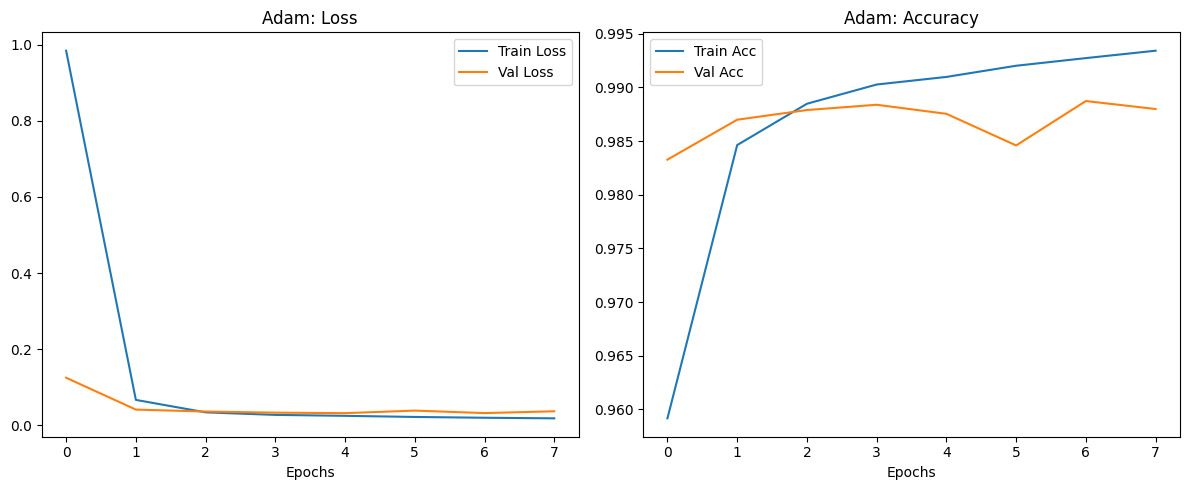

In [46]:
# Plot Training vs Validation metrics for the Adam optimizer
import matplotlib.pyplot as plt

if 'adam' in results:
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(results['adam']['loss'], label='Train Loss')
    plt.plot(results['adam']['val_loss'], label='Val Loss')
    plt.title('Adam: Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(results['adam']['accuracy'], label='Train Acc')
    plt.plot(results['adam']['val_accuracy'], label='Val Acc')
    plt.title('Adam: Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Adam results not found in dictionary.")

150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step

Classification Report (Excluding Padding):
              precision    recall  f1-score   support

           O       0.00      0.00      0.00         0

    accuracy                           0.98    124713
   macro avg       0.50      0.49      0.49    124713
weighted avg       1.00      0.98      0.99    124713



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 2, does not match size of target_names, 1
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to con

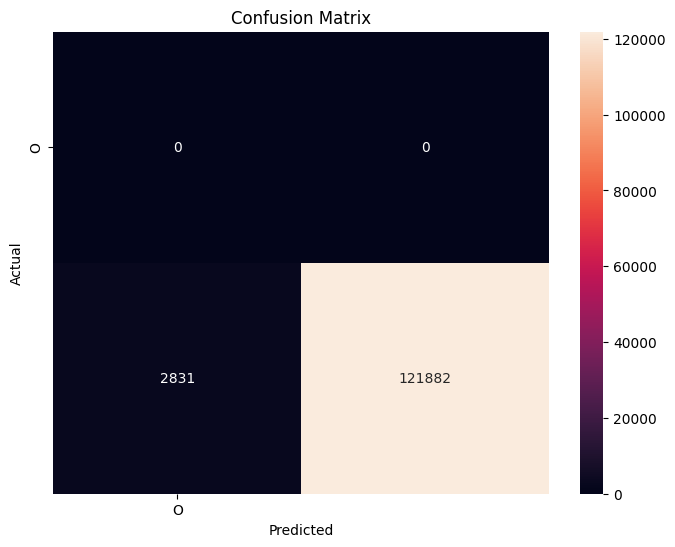

In [47]:
# Load saved model and evaluate on test set
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

model_path = "BC5CDR_ner_model.h5"
if os.path.exists(model_path):
    final_model = load_model(model_path)
    y_pred = final_model.predict(X_test)

    # Convert probabilities to class indices
    y_pred_idx = np.argmax(y_pred, axis=-1).flatten()
    y_test_idx = np.argmax(y_test, axis=-1).flatten()

    # Filter out padding index (0)
    mask = (y_test_idx != 0)

    y_test_masked = y_test_idx[mask]
    y_pred_masked = y_pred_idx[mask]

    if len(y_test_masked) > 0:
        print("\nClassification Report (Excluding Padding):")
        # Labels in report correspond to indices in label_list shifted by 1
        # So index 1 is label_list[0], etc.
        unique_labels = np.unique(np.concatenate([y_test_masked, y_pred_masked]))
        target_names = [label_list[i-1] for i in unique_labels if i > 0]

        print(classification_report(y_test_masked, y_pred_masked, labels=unique_labels, target_names=target_names))

        # Confusion Matrix
        cm = confusion_matrix(y_test_masked, y_pred_masked, labels=unique_labels)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names)
        plt.title("Confusion Matrix")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
    else:
        print("No non-padding tokens found in the test set to evaluate.")
else:
    print(f"Model file {model_path} not found.")